# 10. Optimizare neliniara - Orientarea optima a panourilor solare (India)

**Etapa III: Optimizare neliniara (suport decizional prescriptiv) - a treia problema**

**Scop:** gasirea unghiului de inclinare (tilt) la care un panou fix capteaza maxim de energie pe parcursul zilei. Spre deosebire de primele doua probleme (zeci de variabile - cate una pe ora), aceasta este o problema de optimizare cu **o singura variabila continua si limite fizice** (0-90 grade), ilustrand un alt tip de optimizare neliniara.

> **Nota metodologica:** datele masurate de la centrala India contin iradierea efectiva, dar nu si geometria soarelui necesara pentru a re-proiecta resursa pe diferite unghiuri. De aceea folosim aici un **model geometric simplificat** al pozitiei soarelui (elevatie tip semi-sinus intre rasarit si apus) - suficient pentru a ilustra problema de optimizare, dar nu un model fotovoltaic de productie. Este declarat explicit ca atare.

## Setup

In [1]:
import sys, time
from pathlib import Path
import warnings
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.optimization.optimizer import (
    solar_elevation, solar_captured_energy, solve_solar_tilt,
)
from src.utils.plotting import setup_style, PALETA
setup_style()
warnings.filterwarnings("ignore")
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Setup OK.")

Setup OK.


## 1. Modelul geometric al soarelui

Modelam inaltimea (elevatia) soarelui ca un semi-sinus: zero la rasarit (ora 6) si apus (ora 18), maxim la pranz. Pentru India vara, soarele urca foarte sus (~82 grade la pranz). Cu cat soarele e mai sus, cu atat radiatia disponibila e mai mare (drum atmosferic mai scurt) - modelat prin `sin(elevatie)`.

Un panou inclinat la unghiul `tilt` (fata de orizontala) capteaza maxim cand razele cad perpendicular pe el, adica atunci cand `tilt` egaleaza unghiul zenital al soarelui (`90 - elevatie`). Proiectia razelor pe panou este `cos(zenit - tilt)`.

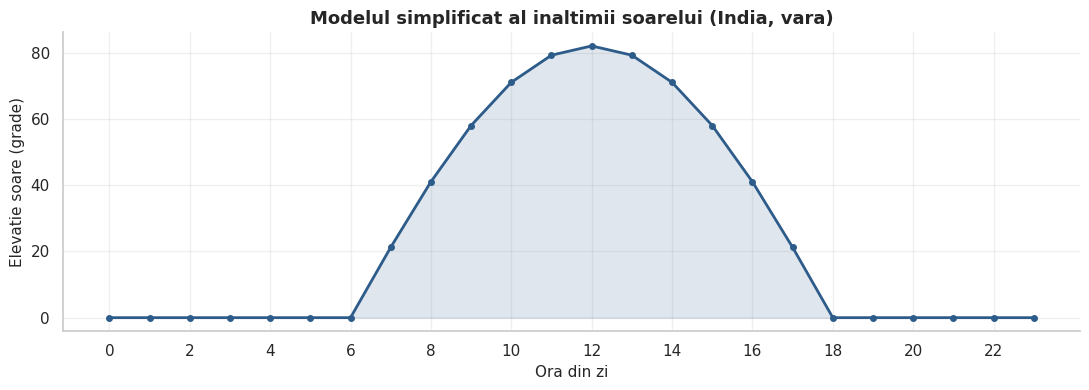

Elevatie maxima (pranz): 82 grade


In [2]:
hours = np.arange(24)
elev = solar_elevation(hours)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hours, elev, color=PALETA["primary"], lw=2, marker="o", ms=4)
ax.fill_between(hours, 0, elev, color=PALETA["primary"], alpha=0.15)
ax.set_xlabel("Ora din zi"); ax.set_ylabel("Elevatie soare (grade)")
ax.set_title("Modelul simplificat al inaltimii soarelui (India, vara)")
ax.set_xticks(range(0, 24, 2)); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_10_1_elevatie_soare.png", dpi=130, bbox_inches="tight")
plt.show()
print("Elevatie maxima (pranz): %.0f grade" % elev.max())

## 2. Formularea si rezolvarea problemei

- **Variabila de decizie**: `tilt` in [0, 90] grade (limita fizica - panoul nu se inclina mai mult).
- **Obiectiv (maximizat)**: energia totala captata pe zi = suma orara a `sin(elevatie) x cos(zenit - tilt)` (doar cand soarele e sus si proiectia e pozitiva).
- **Constrangeri**: doar bounds-urile pe unghi (problema de optimizare cu o variabila marginita).

Folosim acelasi optimizator SLSQP. Fiind o problema cu o singura variabila, converge in cateva iteratii.

In [3]:
t = time.time()
out = solve_solar_tilt(hours)
print(f"Optimizare in {time.time()-t:.3f}s | convergenta: {out['result'].success}")
print(f"\nUnghi optim de inclinare: {out['tilt_opt']:.1f} grade")
print(f"Energie captata (optim):     {out['energy_opt']:.3f}")
print(f"Energie captata (orizontal): {out['energy_flat']:.3f}")
print(f"CASTIG fata de panou orizontal: +{out['gain_pct']:.1f}%")

Optimizare in 0.002s | convergenta: True

Unghi optim de inclinare: 26.9 grade
Energie captata (optim):     8.141
Energie captata (orizontal): 7.260
CASTIG fata de panou orizontal: +12.1%


## 3. Curba energiei in functie de unghi

Pentru a vedea ca optimul gasit este real, trasam energia captata pentru toate unghiurile de la 0 la 90 de grade. Optimul este varful curbei - punctul unde derivata e zero.

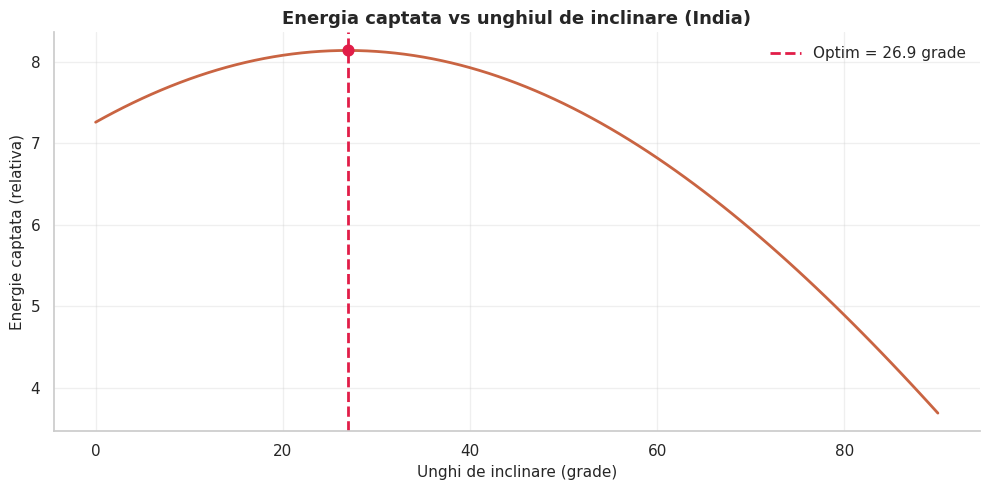

Figura salvata: reports/figures/fig_10_2_energie_vs_tilt.png


In [4]:
tilts = np.linspace(0, 90, 91)
energy = [solar_captured_energy(t, hours) for t in tilts]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tilts, energy, color=PALETA["secondary"], lw=2)
ax.axvline(out["tilt_opt"], color="#E11D48", ls="--", lw=2, label=f"Optim = {out['tilt_opt']:.1f} grade")
ax.scatter([out["tilt_opt"]], [out["energy_opt"]], color="#E11D48", zorder=5, s=60)
ax.set_xlabel("Unghi de inclinare (grade)"); ax.set_ylabel("Energie captata (relativa)")
ax.set_title("Energia captata vs unghiul de inclinare (India)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_10_2_energie_vs_tilt.png", dpi=130, bbox_inches="tight")
plt.show()
print("Figura salvata: reports/figures/fig_10_2_energie_vs_tilt.png")

## 4. Captarea orara: panou optim vs orizontal

Comparam cat capteaza, ora de ora, un panou la unghiul optim fata de unul orizontal. Panoul inclinat castiga in special dimineata si seara, cand soarele e jos si razele cad razant pe o suprafata orizontala.

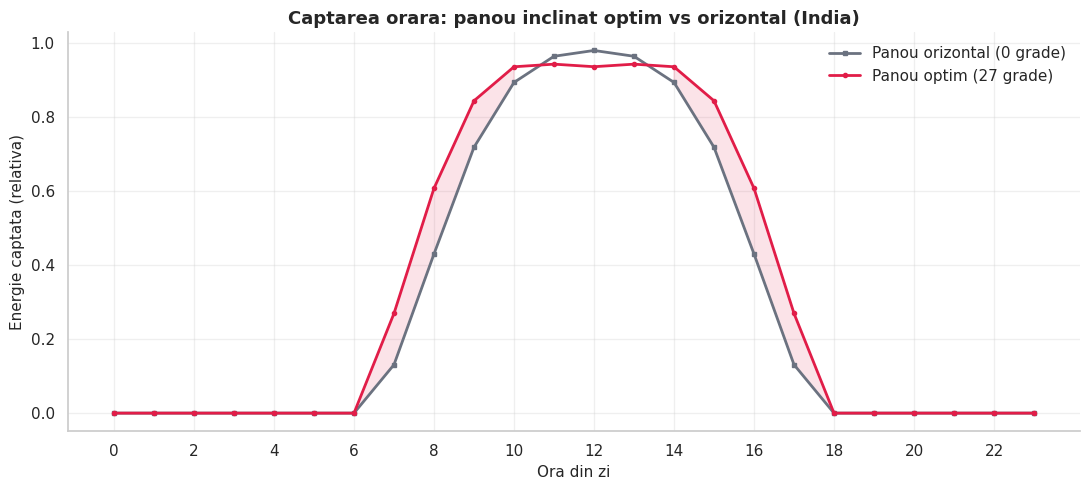

Figura salvata: reports/figures/fig_10_3_captare_orara.png


In [5]:
zenith = 90 - elev
up = elev > 0
beam = np.sin(np.radians(np.clip(elev, 0, None)))
cap_opt = np.where(up, beam * np.clip(np.cos(np.radians(zenith - out["tilt_opt"])), 0, None), 0)
cap_flat = np.where(up, beam * np.clip(np.cos(np.radians(zenith - 0)), 0, None), 0)
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(hours, cap_flat, color=PALETA["neutral"], lw=2, marker="s", ms=3, label="Panou orizontal (0 grade)")
ax.plot(hours, cap_opt, color="#E11D48", lw=2, marker="o", ms=3, label=f"Panou optim ({out['tilt_opt']:.0f} grade)")
ax.fill_between(hours, cap_flat, cap_opt, where=(cap_opt>=cap_flat), color="#E11D48", alpha=0.12)
ax.set_xlabel("Ora din zi"); ax.set_ylabel("Energie captata (relativa)")
ax.set_title("Captarea orara: panou inclinat optim vs orizontal (India)")
ax.set_xticks(range(0, 24, 2)); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_10_3_captare_orara.png", dpi=130, bbox_inches="tight")
plt.show()
print("Figura salvata: reports/figures/fig_10_3_captare_orara.png")

## 5. Concluzii si incheierea Etapei III

Unghiul optim gasit (in jurul a 27 de grade) aduce un castig de aproximativ 12% fata de montarea orizontala - un rezultat coerent cu regulile practice de instalare a panourilor (unghi apropiat de latitudinea locului). Aceasta a treia problema completeaza tabloul optimizarii din lucrare cu un al treilea tip metodologic: o problema de **dimensiune mica, cu variabila continua si limite fizice**, in contrast cu problemele de dispatch (zeci de variabile, multe constrangeri) din primele doua.

**Bilantul Etapei III** - trei probleme de optimizare neliniara, rezolvate cu acelasi motor SLSQP, acoperind trei tipuri de decizie energetica:
1. **Dispatch baterie (Spania)** - arbitraj de pret, obiectiv economic, multe variabile temporale.
2. **Load shifting (USA)** - reorganizarea cererii sub tarif time-of-use, cu energie conservata.
3. **Orientare panouri (India)** - optimizare fizica continua cu limite, model geometric.

Toate trei demonstreaza componenta prescriptiva a platformei: transformarea predictiilor in decizii actionabile. Pasul urmator este Etapa IV (integrarea LLM), care va explica aceste recomandari in limbaj natural.